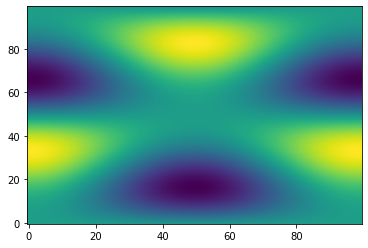

In [3]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import os
from numpy import sqrt
import matplotlib
from matplotlib import gridspec
from matplotlib.pyplot import *
from scipy.interpolate import griddata

from mpl_toolkits.axes_grid1 import make_axes_locatable

def c1funGeneral(B,C, gamma, delta, phi):
    if(abs(B-C) < 0.0000001):
        #c1 = abs((-10**(-9)))/(2.0*(gamma*math.cos(phi)+delta*math.sin(phi)))
        c1 = (10**(-16))/(2.0*(gamma*np.cos(phi)+delta*np.sin(phi)))
        return c1
    else:
        # why did i take the absolute value in the old expression?
        c1 = (B-C)/(2.0*(gamma*np.cos(phi)+delta*np.sin(phi)))
        #c1 = (B-C)/(2.0*(gamma*math.cos(phi)+delta*math.sin(phi)))
        return c1

def c0funGeneral(A, C1, phi, x,y,):
    G1 = 4.0*np.pi/(np.sqrt(3.0))
    c0 = A - 2.0 * C1 * np.cos(phi - G1 * y) - 4.0 * C1 * np.cos(G1 * y / 2.0 + phi) * np.cos(np.sqrt(3.0) * G1 * x / 2.0)
    return c0

def phifunGeneral(alpha, beta, gamma, delta, D):
    # maybe add the same conditions as old expression to account for which quadrant we're in
    #phi = math.atan((delta*alpha - 2.0*gamma*beta)/((D*(delta/beta)-1.0)*beta*delta))
    #if(beta==0.0):
    #    beta=10**(-10)
    #if(delta==0.0 or beta==0.0):
    #    phi = math.pi/2.0
    #else:
    phi = np.arctan((1.0/(delta/beta*D-1.0)*((delta*alpha-beta*gamma)/(beta*delta)))-(gamma)/(delta))
    #if phi<-math.pi/2.0:
    #    return  phi+math.pi
    #else:
    return phi

def alphaGammafun(x1,y1,x2,y2):
    G1 = 4.0*np.pi/(np.sqrt(3.0))
    m1 = np.cos(np.sqrt(3.0)*G1*x1/2.0)
    m2 = np.cos(np.sqrt(3.0)*G1*x2/2.0)
    a1 = np.cos(G1*y1) - np.cos(G1*y2)
    a3 = 2.0*np.cos(G1*y1/2.0) * m1 - 2.0*np.cos(G1*y2/2.0)* m2
    alpha = a1 + a3
    return alpha

def betaDeltafun(x1,y1,x2,y2):
    G1 = 4.0*np.pi/(np.sqrt(3.0))
    m1 = np.cos(np.sqrt(3.0)*G1*x1/2.0)
    m2 = np.cos(np.sqrt(3.0)*G1*x2/2.0)
    a2 = np.sin(G1*y1) - np.sin(G1*y2)
    a4 = 2.0*np.sin(G1*y1/2.0) * m1 - 2.0*np.sin(G1*y2/2.0)* m2
    alpha = a2 - a4
    return alpha


def getEnergy(x,y,d):
    Bx = 0.0
    By = 0.0
    Ax = 0.0
    Ay = 1.0/np.sqrt(3.0)
    Cx = 0.0
    Cy = 2.0/np.sqrt(3.0)

    B = -0.39969

    C = -0.42777

    A = -0.37776

    #D = (A-B)/(B-C)
    #print D

    if(abs(B-C) < 0.0000001):
        print("we have a singularity")
        D = (A-B)/(10**(-16))
        #D = (A-B)/(B-C)
    else:
        D = (A-B)/(B-C)

    alpha = alphaGammafun(Ax,Ay,Bx,By)
    beta = betaDeltafun(Ax,Ay,Bx,By)
    gamma = alphaGammafun(Bx,By,Cx,Cy)
    delta = betaDeltafun(Bx,By,Cx,Cy)

    #print alpha, beta, gamma, delta

    phiRPA = phifunGeneral(alpha, beta, gamma, delta, D)
    #phiRPAVect.append(phiRPA)
    #print phiRPA

    c1valueRPA = c1funGeneral(B,C, gamma, delta, phiRPA)
    #c1valueRPAVect.append(c1valueRPA)

    c0valueRPA = c0funGeneral(A, c1valueRPA, phiRPA, Ax, Ay)
    #c0valueRPAVect.append(c0valueRPA)

    enerRPA = energy3d_gg(c0valueRPA,c1valueRPA,phiRPA,x,y,d/2.46)

    return enerRPA

def energy3d_gg(c0,c1,phi,x,y,z):
    acc = 1.0
    G1 = 4.0*np.pi/(np.sqrt(3.0)*acc)
    f1 = 2.0*c1*np.cos(phi-G1*y) + 4.0*c1*np.cos(G1*y/2.0 + phi)*np.cos(np.sqrt(3.0)*G1*x/2.0)
    U = c0 + f1
    return U

dx = np.linspace(0,1,100)
dy = np.linspace(0,np.sqrt(3),100)
Newx = []
Newy = []
Newz = []

for x in dx:
    for y in dy:
        zdata = getEnergy(x,y,0)
        Newx.append(x)
        Newy.append(y)
        Newz.append(zdata)
        
zdataN=griddata((Newx,Newy),Newz,(dx[None,:], dy[:,None]), method='cubic')
im = plt.imshow(zdataN,origin="lower",aspect="auto")